#### 1. Download and load the Breast Cancer Wisconsin (Diagnostic) dataset.

In [4]:
import pandas as pd

columns = [
    "ID", "Diagnosis",
    "radius_mean", "texture_mean", "perimeter_mean", "area_mean",
    "smoothness_mean", "compactness_mean", "concavity_mean",
    "concave_points_mean", "symmetry_mean", "fractal_dimension_mean",
    "radius_se", "texture_se", "perimeter_se", "area_se",
    "smoothness_se", "compactness_se", "concavity_se",
    "concave_points_se", "symmetry_se", "fractal_dimension_se",
    "radius_worst", "texture_worst", "perimeter_worst",
    "area_worst", "smoothness_worst", "compactness_worst",
    "concavity_worst", "concave_points_worst", "symmetry_worst",
    "fractal_dimension_worst"
]

data = pd.read_csv("wdbc.data", header=None, names=columns)

#### 2. Perform exploratory data analysis and data preprocessing.

**Oberving the shape of the dataset**

In [12]:
print("The dataset has", data.shape[0], "rows and", data.shape[1], "columns.")

The dataset has 569 rows and 32 columns.


**Checking the datatype of each column**

In [8]:
print("\nData Types:")
data.dtypes


Data Types:


ID                           int64
Diagnosis                   object
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave_points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave_points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst          float64
concavity_worst     

#### 3. Check for missing values and prepare the dataset for classification.

**Checking for missing values in the dataset**

In [9]:
print("\nMissing Values:")
print(data.isnull().sum())


Missing Values:
ID                         0
Diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave_points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave_points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave_points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


There are no missing values in the dataset

**Checking for duplicate rows in the dataset**

In [10]:
print("\nDuplicate Rows:", data.duplicated().sum())


Duplicate Rows: 0


There are no duplicates in the dataset

**Observing the class distribution of the dataset**

In [11]:
print("\nDiagnosis Distribution:")
print(data["Diagnosis"].value_counts())


Diagnosis Distribution:
Diagnosis
B    357
M    212
Name: count, dtype: int64


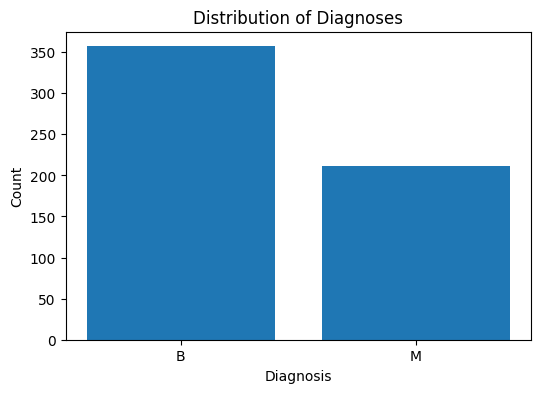

In [14]:
# bar chart for diagnosis distribution
import matplotlib.pyplot as plt

diagnosis_counts = data["Diagnosis"].value_counts()
plt.figure(figsize=(6,4))
plt.bar(diagnosis_counts.index, diagnosis_counts.values)
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.title("Distribution of Diagnoses")
plt.show()

The dataset is slightly imbalanced

**Drop the ID column**

In [15]:
data = data.drop("ID", axis=1)

**Encode the target variable**

In [16]:
data["Diagnosis"] = data["Diagnosis"].map({
    "M": 0,
    "B": 1
})

**Seperate features and target**

In [18]:
X = data.drop("Diagnosis", axis=1)
y = data["Diagnosis"]

print("Feature Matrix:", X.shape)
print("Target Vector :", y.shape)

Feature Matrix: (569, 30)
Target Vector : (569,)


#### 4. Split the dataset into training and testing sets.

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

**Handling the class imabalance**

The original dataset contains:

* Benign = 357
* Malignant = 212

Without stratify, the train and test sets might end up with different class proportions, which can bias the evaluation.

**Feature standardization**

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [21]:
print("Training Set:", X_train.shape)
print("Testing Set :", X_test.shape)

print("\nTraining Class Distribution:")
print(y_train.value_counts())

print("\nTesting Class Distribution:")
print(y_test.value_counts())

Training Set: (455, 30)
Testing Set : (114, 30)

Training Class Distribution:
Diagnosis
1    285
0    170
Name: count, dtype: int64

Testing Class Distribution:
Diagnosis
1    72
0    42
Name: count, dtype: int64


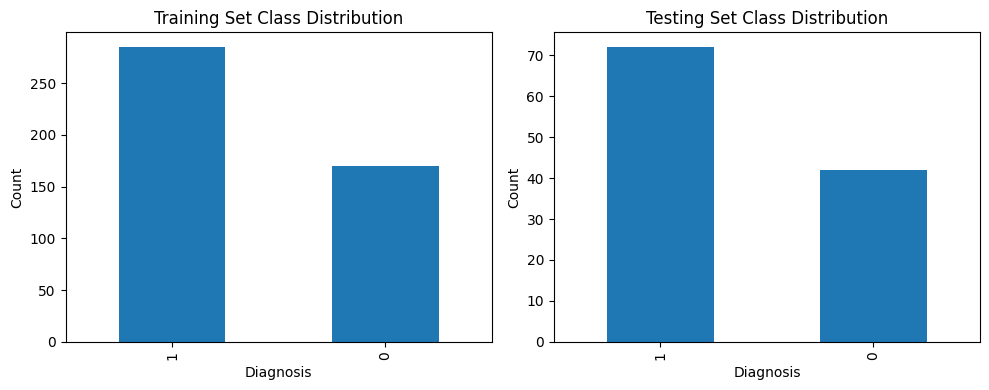

In [26]:
# graphs for training and testing class distribution
plt.figure(figsize=(10,4))

# Training set
plt.subplot(1, 2, 1)
y_train.value_counts().plot(kind='bar')
plt.title('Training Set Class Distribution')
plt.xlabel('Diagnosis')
plt.ylabel('Count')

# Testing set
plt.subplot(1, 2, 2)
y_test.value_counts().plot(kind='bar')
plt.title('Testing Set Class Distribution')
plt.xlabel('Diagnosis')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

#### 5. Train a Logistic Regression classifier.


In [27]:
from sklearn.linear_model import LogisticRegression

In [28]:
log_model = LogisticRegression(random_state=42)

In [29]:
log_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [30]:
y_pred_log = log_model.predict(X_test)

In [31]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_log
})

comparison.head(10)

,Actual,Predicted
0,0,0
1,1,1
2,0,0
3,1,1
4,0,0
5,1,1
6,1,1
7,0,0
8,0,0
9,0,0


In [32]:
print("Number of Coefficients:", len(log_model.coef_[0]))
print("Intercept:", log_model.intercept_)

Number of Coefficients: 30
Intercept: [0.30220757]


**Evaluate the logistic regression value**

In [34]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred_log)
precision = precision_score(y_test, y_pred_log)
recall = recall_score(y_test, y_pred_log)
f1 = f1_score(y_test, y_pred_log)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print("\nClassification Report")
print(classification_report(y_test, y_pred_log,
                            target_names=["Malignant", "Benign"]))


Accuracy : 0.9824561403508771
Precision: 0.9861111111111112
Recall   : 0.9861111111111112
F1 Score : 0.9861111111111112

Classification Report
              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



**Interpretation**

* Accuracy -> The model correctly classified 98.25% of the samples in the test dataset. This indicates that the model has excellent overall classification performance. 

* Precision -> Precision measures how many samples predicted as Benign were actually Benign. A precision of 98.61% means that when the model predicts a tumor as Benign, it is correct approximately 99 out of 100 times. This indicates a very low number of false positive predictions.

* Recall -> Recall measures how many actual Benign cases were correctly identified. A recall of 98.61% means that the model successfully identified almost all Benign tumors, missing only a very small number of actual Benign cases.


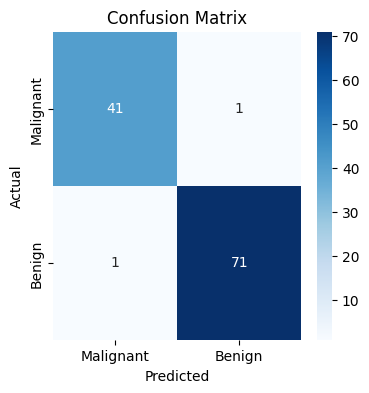

In [36]:
# confusion matrix graph
import seaborn as sns
conf_matrix = confusion_matrix(y_test, y_pred_log)
plt.figure(figsize=(4,4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=["Malignant", "Benign"], yticklabels=["Malignant", "Benign"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#### 6. Train a K Nearest Neighbors (KNN) classifier.

**Finding optimal value for k using cross validation**

In [67]:
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

In [68]:
# find optimal value for k using cross validation, keeping range of k from 1 to 10

k_values = range(1, 11)

mean_accuracy = []

for k in k_values:

    knn = KNeighborsClassifier(n_neighbors=k)

    scores = cross_val_score(
        knn,
        X_train,
        y_train,
        cv=5,
        scoring='accuracy'
    )

    mean_accuracy.append(scores.mean())

    print(f"K = {k} | Mean Accuracy = {scores.mean():.4f} | Std = {scores.std():.4f}")

K = 1 | Mean Accuracy = 0.9451 | Std = 0.0197
K = 2 | Mean Accuracy = 0.9516 | Std = 0.0300
K = 3 | Mean Accuracy = 0.9692 | Std = 0.0245
K = 4 | Mean Accuracy = 0.9670 | Std = 0.0231
K = 5 | Mean Accuracy = 0.9670 | Std = 0.0209
K = 6 | Mean Accuracy = 0.9692 | Std = 0.0176
K = 7 | Mean Accuracy = 0.9692 | Std = 0.0213
K = 8 | Mean Accuracy = 0.9714 | Std = 0.0192
K = 9 | Mean Accuracy = 0.9692 | Std = 0.0162
K = 10 | Mean Accuracy = 0.9648 | Std = 0.0189


In [69]:
best_k = k_values[np.argmax(mean_accuracy)]

print("\nBest K:", best_k)
print("Best Cross Validation Accuracy:", max(mean_accuracy))


Best K: 8
Best Cross Validation Accuracy: 0.9714285714285715


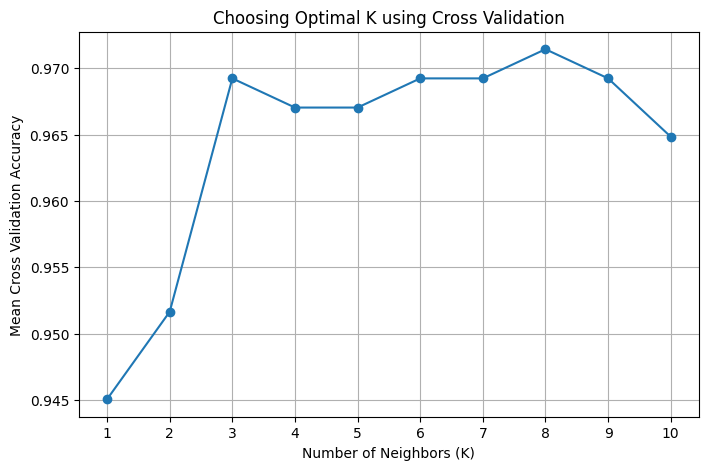

In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(k_values, mean_accuracy, marker='o')

plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Mean Cross Validation Accuracy")
plt.title("Choosing Optimal K using Cross Validation")

plt.xticks(k_values)
plt.grid(True)

plt.show()

**Training knn model using best k**

In [72]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=8)

In [73]:
knn_model.fit(X_train, y_train)

,n_neighbors,8
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [74]:
y_pred_knn = knn_model.predict(X_test)

In [75]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_knn
})

comparison.head(10)

,Actual,Predicted
0,0,0
1,1,1
2,0,0
3,1,1
4,0,0
5,1,1
6,1,1
7,0,0
8,0,0
9,0,0


In [76]:
print(knn_model)

KNeighborsClassifier(n_neighbors=8)


In [77]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred_knn)
precision = precision_score(y_test, y_pred_knn)
recall = recall_score(y_test, y_pred_knn)
f1 = f1_score(y_test, y_pred_knn)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print("\nClassification Report")
print(classification_report(
    y_test,
    y_pred_knn,
    target_names=["Malignant", "Benign"]
))


Accuracy : 0.9736842105263158
Precision: 0.9726027397260274
Recall   : 0.9861111111111112
F1 Score : 0.9793103448275862

Classification Report
              precision    recall  f1-score   support

   Malignant       0.98      0.95      0.96        42
      Benign       0.97      0.99      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



<Axes: >

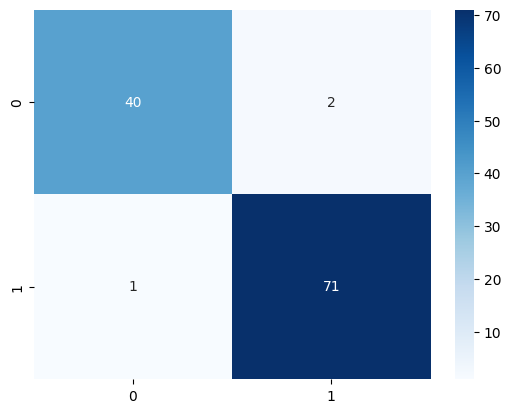

In [78]:
# confusion matrix graph
import seaborn as sns
conf_matrix = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')

**Interpretation**

* Accuracy -> The KNN classifier correctly classified 97.37% of the test samples, matching the reported evaluation accuracy.

* Precision -> A precision of 97.26% indicates that when the KNN model predicts a tumor as Benign, it is correct approximately 97 out of 100 times.

* Recall -> A recall of 98.61% means the model successfully identified nearly all actual Benign cases.

* F1 Score -> The F1 score of 97.93% shows a strong balance between precision and recall for the KNN classifier.

#### 8. Compare the performance of the two classifiers using a comparison table.


In [80]:
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Logistic Regression": [
        0.982456,
        0.986111,
        0.986111,
        0.986111
    ],
    "KNN (K=16)": [
        0.973684,
        0.972602,
        0.986111,
        0.979310
    ]
})


comparison

,Metric,Logistic Regression,KNN (K=16)
0,Accuracy,0.982456,0.973684
1,Precision,0.986111,0.972602
2,Recall,0.986111,0.986111
3,F1 Score,0.986111,0.979310


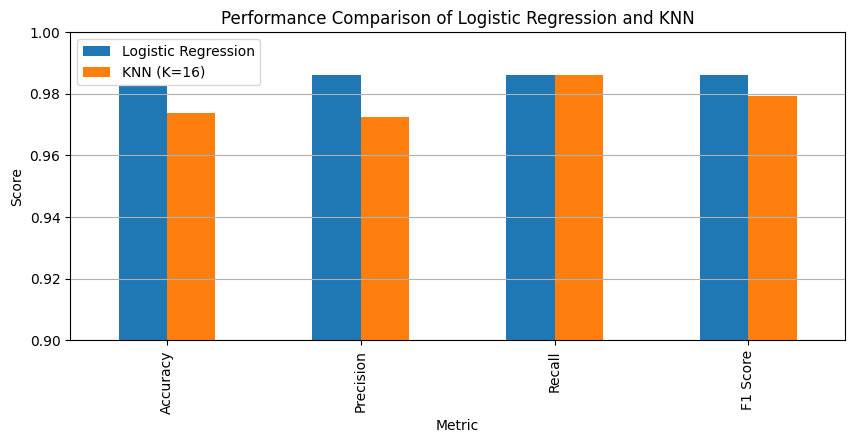

In [81]:
import matplotlib.pyplot as plt

comparison.set_index("Metric").plot(
    kind="bar",
    figsize=(10,4)
)

plt.title("Performance Comparison of Logistic Regression and KNN")
plt.ylabel("Score")
plt.ylim(0.90, 1.00)
plt.grid(axis="y")

plt.show()